# ICS 3202: Artificial Intelligence — Project Deliverable 1
## Dataset Discovery & Exploration

**Semester Project:** *MloHub — An Affordable Multi-Tenant Mobile Food Ordering and Business Intelligence Platform for Small Food Vendors*

**Programme:** BSc. Informatics & Computer Science, Strathmore University
**Deliverable:** 1 of the semester project (Dataset identification + exploration)
**Selected dataset:** Food Demand Forecasting (Genpact / Analytics Vidhya Machine Learning Hackathon 2018)
**Notebook:** `FoodDemandForecasting_Exploration.ipynb`
**Repository:** `SemProject_MLEngine`


---

### What this notebook contains

| Section | Content | Marks |
|---|---|---|
| 1 | Discovery of all relevant open-source datasets, with the expected output variable for each | — |
| 2 | Selection of the most appropriate dataset, with justification | — |
| 3 | Loading the dataset | — |
| 4 (a) | How many rows and columns are contained in the dataset? | 3 |
| 4 (b) | What datatypes are contained in the dataset? | 3 |
| 4 (c) | Is the dataset complete, i.e. no missing values? | 2 |
| 4 (d) | First 15 rows + last 20 rows merged into `df_sample`, displayed | 4 |
| 5 | Supplementary exploration and suitability verdict | — |

---
# 1. Dataset Discovery

**Instruction 1:** *Discover all possible open-source datasets that are relevant to your research area.*
**Instruction 2:** *For each dataset, identify at least one variable that would serve as the expected output of the final application.*

### 1.1 What our application has to predict

MloHub is a multi-tenant food-ordering platform for small restaurants, kiosks and home-based cooks. Section 7 of our project concept defines the machine-learning component as a **food-demand prediction model**:

> *"Tomorrow between 12:00 PM and 2:00 PM, approximately 40 portions of Chicken Pilau may be required."*

So the ML engine is a **supervised regression** problem:

$$\hat{y} = f(\text{vendor},\ \text{menu item},\ \text{time window},\ \text{price},\ \text{promotion},\ \text{location})$$

where $\hat{y}$ = **number of portions/orders expected** for a given meal, at a given vendor, in a given time window. Any candidate dataset must therefore contain a **countable demand variable** that can act as the label $y$.

A secondary analytics goal (Section 6 of the concept) is **market-basket analysis** — *"which foods are normally bought together?"* — which needs transaction/basket-level data instead.

### 1.2 Open-source datasets discovered

Datasets were searched on Kaggle, the UCI Machine Learning Repository, Analytics Vidhya, Maven Analytics and the Humanitarian Data Exchange (HDX), using the search terms *food demand*, *meal orders*, *restaurant sales*, *food delivery* and *market basket*.

| # | Dataset (source) | Scale | Why it is relevant to MloHub | **Expected output variable (label)** |
|---|---|---|---|---|
| 1 | **Food Demand Forecasting** — Genpact / Analytics Vidhya hackathon; Kaggle mirrors `kannanaikkal/food-demand-forecasting` and `ghoshsaptarshi/av-genpact-hack-dec2018` | ~456,548 rows × 9 cols + 2 lookup tables | Weekly orders per **meal × fulfilment centre**, with price, discount and promotion flags — structurally identical to *meal × vendor* demand in MloHub | **`num_orders`** — number of orders (portions) placed |
| 2 | **Store Item Demand Forecasting Challenge** (Kaggle, `demand-forecasting-kernels-only`) | 913,000 rows | Clean 5-year daily item-level demand series; good for benchmarking forecasting algorithms | **`sales`** — units sold per item per store per day |
| 3 | **Rossmann Store Sales** (Kaggle, `rossmann-store-sales`) | ~1,017,209 rows | Daily sales with promotion, holiday and competition features — shows how promotions shift demand, mirroring MloHub's "featured meal" | **`Sales`** (or `Customers`) |
| 4 | **Restaurant Orders / Restaurant Sales** (Maven Analytics Data Playground) | ~12,000 order-item rows | Real menu-item-level restaurant orders with timestamps — closest to a single MloHub tenant's order log | **`quantity` / item count per order** |
| 5 | **Instacart Market Basket Analysis** (Kaggle competition, `instacart-market-basket-analysis`) | ~3.4 million orders | Basket composition and order hour-of-day; supports *"which foods are bought together?"* and reorder prediction | **`reordered`** (0/1) and the basket itemset |
| 6 | **Online Retail II** (UCI ML Repository) | ~1,067,371 invoice lines | Transactional invoices with quantity, unit price and timestamp; classic association-rule and RFM dataset | **`Quantity`** per invoice line |
| 7 | **Brazilian E-Commerce Public Dataset by Olist** (Kaggle, `olistbr/brazilian-ecommerce`) | ~100,000 orders | Multi-seller marketplace with order status timestamps, delivery and reviews — matches MloHub's order-tracking and rating data | **`review_score`** or delivery duration |
| 8 | **Zomato Bangalore Restaurants** (Kaggle, `himanshupoddar/zomato-bangalore-restaurants`) | ~51,700 rows | Restaurant-level attributes (cuisine, cost, online ordering, votes) — useful for menu/pricing benchmarking, not for demand | **`rate`** (rating) or `approx_cost(for two people)` |
| 9 | **Online Food Delivery Preferences — Bengaluru Region** (Kaggle, `benroshan/online-food-delivery-preferencesbangalore-region`) | ~388 rows × 55 cols | Survey of customer attitudes to food-delivery apps; useful for requirements validation only — far too small to train on | **`Output`** — whether the customer would reorder (Yes/No) |
| 10 | **Restaurant Revenue Prediction** (Kaggle competition, `restaurant-revenue-prediction`) | 137 train rows | Predicts annual revenue per outlet; interesting business framing but tiny and heavily anonymised | **`revenue`** |
| 11 | **Food.com Recipes and User Interactions** (Kaggle, `shuyangli94/food-com-recipes-and-user-interactions`) | ~230,000 recipes / ~1.1 M reviews | Supports a recipe/meal recommender add-on for the storefront | **`rating`** |
| 12 | **WFP Food Prices for Kenya** (Humanitarian Data Exchange) | Monthly market price series | Kenyan commodity prices — can be joined later as a **cost-of-goods feature** for margin analytics | **`price`** per commodity per market |
| 13 | **Restaurant & Consumer Data (RCdata)** (UCI ML Repository) | ~1,161 ratings | Consumer–restaurant ratings for a recommender baseline | **`rating`** |

> **Summary of instruction 2:** every dataset above has an explicitly named candidate label in the final column. Datasets 1–4 expose a *count of items sold*, which is exactly the quantity MloHub's demand engine must output; datasets 5–6 expose basket structure; datasets 7–13 expose satisfaction, price or revenue variables that support secondary analytics rather than the core prediction.

---
# 2. Selecting the Most Appropriate Dataset

**Selected: Dataset #1 — Food Demand Forecasting (Genpact / Analytics Vidhya ML Hackathon 2018).**

### 2.1 Why this one

| Requirement from the MloHub concept | How this dataset satisfies it |
|---|---|
| A **countable demand label** to predict | `num_orders` is the explicit target variable of the original hackathon |
| **Multi-tenant** structure (many vendors on one platform) | 77 fulfilment centres in one table — a direct analogue of many restaurants on one platform, each with separate data |
| **Per-menu-item** granularity | 51 meals, each with a category and cuisine, exactly like an MloHub menu |
| **Price and discount** effects on demand | `base_price` and `checkout_price`; their difference is the effective discount |
| **Promotion/featuring** effects | `emailer_for_promotion` and `homepage_featured` — the same levers as MloHub's "featured meal" storefront slot |
| **Time dimension** for forecasting | 145 consecutive weeks of history per centre–meal pair |
| **Location context** | `city_code`, `region_code`, `center_type`, `op_area` — analogous to MloHub's delivery areas |
| **Open and legally reusable** | Released publicly for a public hackathon; contains **no personal data**, so no ethical/DPA-2019 exposure |
| **Large enough to train on** | 456,548 labelled observations — sufficient for gradient-boosted trees and sequence models |

### 2.2 Column-by-column mapping to the MloHub schema

| Dataset column | MloHub equivalent (Django model field) |
|---|---|
| `center_id` | `Restaurant` / tenant ID |
| `meal_id` | `MenuItem` ID |
| `category`, `cuisine` | `MenuItem.category`, `MenuItem.cuisine` |
| `week` | Order time bucket (MloHub will use day + hour window) |
| `checkout_price` | `OrderItem.price_paid` |
| `base_price` | `MenuItem.base_price` |
| `emailer_for_promotion`, `homepage_featured` | Promotion / featured-item flags in the storefront |
| `city_code`, `region_code`, `op_area` | Delivery area attributes |
| **`num_orders`** | **`OrderItem.quantity` aggregated per item per time window — the value the ML engine must predict** |

### 2.3 Known limitations (and how we will handle them)

1. **Weekly, not hourly.** Our concept predicts a 12:00–2:00 PM lunch window. We will train the engine on this dataset at weekly granularity to establish the modelling pipeline, then re-fit on MloHub's own timestamped order data once live vendors generate it.
2. **Indian meal-delivery context.** Meal IDs and prices are anonymised and non-Kenyan. Categories (Beverages, Rice Bowl, Starters…) still transfer conceptually; local re-training is planned.
3. **No customer identifier.** Basket analysis (*"which foods are bought together?"*) cannot be done here — we will use **Instacart** or **Online Retail II** for that sub-question.
4. **Anonymised centres.** No restaurant names or menu text, so no NLP on menus; acceptable for a demand model.

**Verdict:** it is the only discovered dataset that carries a genuine demand label *together with* price, promotion, item and vendor dimensions in one place, so it is the most appropriate choice for the MloHub ML engine.

---
# 3. Environment Setup and Data Loading

In [1]:
# --- Libraries -------------------------------------------------------------
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display settings so wide tables and the 35-row df_sample print in full
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

print("Python :", sys.version.split()[0])
print("pandas :", pd.__version__)
print("numpy  :", np.__version__)

Python : 3.12.3
pandas : 2.2.3
numpy  : 2.4.4


### 3.1 Where the data comes from

The three CSV files are pulled straight from a public GitHub mirror of the hackathon data, so **this notebook runs in Google Colab with no Kaggle account, no API token and no manual upload**. If the files are already sitting next to the notebook (or in a `data/` folder), those local copies are used instead.

| File | Contents |
|---|---|
| `train_file.csv` | Weekly demand per centre–meal pair (the main table) |
| `meal_info.csv` | Lookup: meal category and cuisine |
| `fulfilment_center_info.csv` | Lookup: centre city, region, type and operating area |

*Kaggle alternative (optional):* the same data is published as `kannanaikkal/food-demand-forecasting` and `ghoshsaptarshi/av-genpact-hack-dec2018`.

In [2]:
# --- Data source -----------------------------------------------------------
MIRROR = ("https://raw.githubusercontent.com/Erdos1729/"
          "food-demand-forecasting/master/datasets/")

FILES = {
    "demand":  "train_file.csv",                 # weekly demand  (main table)
    "meals":   "meal_info.csv",                  # meal lookup
    "centers": "fulfilment_center_info.csv",     # centre lookup
}

SEARCH_DIRS = ["data", ".", "/content", "/content/data"]


def load_csv(filename: str) -> pd.DataFrame:
    """Load a CSV from a local copy if one exists, otherwise from the mirror."""
    for folder in SEARCH_DIRS:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            print(f"[local ] {path}")
            return pd.read_csv(path)
    url = MIRROR + filename
    print(f"[remote] {url}")
    return pd.read_csv(url)


demand  = load_csv(FILES["demand"])
meals   = load_csv(FILES["meals"])
centers = load_csv(FILES["centers"])

print("\nFiles loaded successfully.\n")
for label, frame in [("train_file.csv (weekly demand)", demand),
                     ("meal_info.csv (meal lookup)", meals),
                     ("fulfilment_center_info.csv (centre lookup)", centers)]:
    print(f"{label:<45} {frame.shape[0]:>7,} rows x {frame.shape[1]:>2} columns")

[remote] https://raw.githubusercontent.com/Erdos1729/food-demand-forecasting/master/datasets/train_file.csv


[remote] https://raw.githubusercontent.com/Erdos1729/food-demand-forecasting/master/datasets/meal_info.csv
[remote] https://raw.githubusercontent.com/Erdos1729/food-demand-forecasting/master/datasets/fulfilment_center_info.csv

Files loaded successfully.

train_file.csv (weekly demand)                456,548 rows x  9 columns
meal_info.csv (meal lookup)                        51 rows x  3 columns
fulfilment_center_info.csv (centre lookup)         77 rows x  5 columns


### 3.2 A first look at each table

In [3]:
print("train_file.csv — weekly demand per centre-meal pair")
display(demand.head())

print("\nmeal_info.csv — one row per meal")
display(meals.head())

print("\nfulfilment_center_info.csv — one row per fulfilment centre")
display(centers.head())

train_file.csv — weekly demand per centre-meal pair


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40



meal_info.csv — one row per meal


,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian



fulfilment_center_info.csv — one row per fulfilment centre


,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.70
1,13,590,56,TYPE_B,6.70
2,124,590,56,TYPE_C,4.00
3,66,648,34,TYPE_A,4.10
4,94,632,34,TYPE_C,3.60


### 3.3 Building the analysis dataset `df`

The demand table stores `meal_id` and `center_id` as bare foreign keys. Joining the two lookup tables onto it produces a single **analysis-ready, denormalised table** — the same shape the ML engine will consume, and the dataset explored in Section 4.

The join is a `LEFT JOIN`, and the row count is asserted afterwards so that no rows are silently duplicated or dropped.

In [4]:
df = (demand
      .merge(meals,   on="meal_id",   how="left", validate="many_to_one")
      .merge(centers, on="center_id", how="left", validate="many_to_one"))

assert len(df) == len(demand), "Row count changed during the merge!"
print(f"Analysis dataset built: {df.shape[0]:,} rows x {df.shape[1]} columns "
      f"(demand table had {demand.shape[1]} columns before the joins)\n")

display(df.head())

Analysis dataset built: 456,548 rows x 15 columns (demand table had 9 columns before the joins)



,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.00
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages,Thai,647,56,TYPE_C,2.00
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages,Thai,647,56,TYPE_C,2.00
3,1338232,1,55,2139,339.50,437.53,0,0,54,Beverages,Indian,647,56,TYPE_C,2.00
4,1448490,1,55,2631,243.50,242.50,0,0,40,Beverages,Indian,647,56,TYPE_C,2.00


---
# 4. Data Exploration

## (a) How many rows and columns are contained in the dataset? &nbsp;&nbsp;`(3 marks)`

In [5]:
rows, cols = df.shape

print("=" * 62)
print("ANSWER (a)")
print("=" * 62)
print(f"The dataset contains {rows:,} rows and {cols} columns.")
print(f"  Rows    (observations) : {rows:,}")
print(f"  Columns (variables)    : {cols}")
print("=" * 62)

print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"  {i:>2}. {column}")

print("\nBreakdown by source file:")
shape_summary = pd.DataFrame(
    [[f"{demand.shape[0]:,}",  demand.shape[1],  "Weekly demand — main table"],
     [f"{meals.shape[0]:,}",   meals.shape[1],   "Meal lookup"],
     [f"{centers.shape[0]:,}", centers.shape[1], "Fulfilment-centre lookup"],
     [f"{rows:,}",             cols,             "Merged analysis dataset (df)"]],
    index=["train_file.csv", "meal_info.csv", "fulfilment_center_info.csv", "df (merged)"],
    columns=["rows", "columns", "description"])
display(shape_summary)

print(f"In-memory size of df : {df.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")

ANSWER (a)
The dataset contains 456,548 rows and 15 columns.
  Rows    (observations) : 456,548
  Columns (variables)    : 15

Column names:
   1. id
   2. week
   3. center_id
   4. meal_id
   5. checkout_price
   6. base_price
   7. emailer_for_promotion
   8. homepage_featured
   9. num_orders
  10. category
  11. cuisine
  12. city_code
  13. region_code
  14. center_type
  15. op_area

Breakdown by source file:


,rows,columns,description
train_file.csv,"456,548",9,Weekly demand — main table
meal_info.csv,51,3,Meal lookup
fulfilment_center_info.csv,77,5,Fulfilment-centre lookup
df (merged),"456,548",15,Merged analysis dataset (df)


In-memory size of df : 114.7 MB


**Answer (a).** The merged analysis dataset `df` contains **456,548 rows and 15 columns**.

The main file on its own, `train_file.csv`, holds **456,548 rows × 9 columns**; the two lookup tables add 6 further descriptive columns (`category`, `cuisine`, `city_code`, `region_code`, `center_type`, `op_area`). Each row is one **meal × fulfilment centre × week** observation.

---
## (b) What datatypes are contained in the dataset? &nbsp;&nbsp;`(3 marks)`

In [6]:
print("=" * 62)
print("ANSWER (b)")
print("=" * 62)

dtype_table = pd.DataFrame({
    "dtype":         df.dtypes.astype(str),
    "unique_values": df.nunique(),
    "example":       [df[c].iloc[0] for c in df.columns],
})
dtype_table.index.name = "column"
display(dtype_table)

print("Count of columns per datatype:")
print(df.dtypes.astype(str).value_counts().to_string())

print("\nFull structural summary — df.info():")
df.info()

ANSWER (b)


,dtype,unique_values,example
column,,,
id,int64,456548,1379560
week,int64,145,1
center_id,int64,77,55
meal_id,int64,51,1885
checkout_price,float64,1992,136.83
base_price,float64,1907,152.29
emailer_for_promotion,int64,2,0
homepage_featured,int64,2,0
num_orders,int64,1250,177


Count of columns per datatype:
int64      9
float64    3
object     3

Full structural summary — df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
 9   category               456548 non-null  object 
 10  cuisine                456548 non-null  object 
 11  city_code              456548 non-null  int64  
 12  region_code            456548 non-

**Answer (b).** The dataset contains **three datatypes**:

| Datatype | Columns | Meaning |
|---|---|---|
| **Integer** (`int64`) | `id`, `week`, `center_id`, `meal_id`, `emailer_for_promotion`, `homepage_featured`, `num_orders`, `city_code`, `region_code` | Identifiers, the week counter, two binary 0/1 promotion flags, the two location codes, and the order count |
| **Float** (`float64`) | `checkout_price`, `base_price`, `op_area` | Monetary values and the centre's operating area in km² |
| **Text** (`object` / `string` — the label depends on the pandas version) | `category`, `cuisine`, `center_type` | Categorical labels from the two lookup tables |

Two important modelling notes follow from this:

1. **Not every integer is a number to compute with.** `center_id`, `meal_id`, `city_code` and `region_code` are *nominal identifiers* stored as integers. They must be treated as categorical features (embedding or one-hot encoding), never fed to a model as magnitudes — meal 2539 is not "more" than meal 1885.
2. **`emailer_for_promotion` and `homepage_featured` are already binary (0/1)**, so they can be used directly as indicator features.

---
## (c) Is the dataset complete, i.e. no missing values? &nbsp;&nbsp;`(2 marks)`

In [7]:
print("=" * 62)
print("ANSWER (c)")
print("=" * 62)

missing_table = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "percent_missing": (df.isna().mean() * 100).round(2),
})
missing_table.index.name = "column"
display(missing_table)

total_missing = int(df.isna().sum().sum())
duplicate_rows = int(df.duplicated().sum())

print(f"Total missing cells in df        : {total_missing:,} "
      f"(out of {df.size:,} cells)")
print(f"Columns containing any missing   : {int((df.isna().sum() > 0).sum())}")
print(f"Fully duplicated rows            : {duplicate_rows:,}")
print(f"Duplicate (week, center, meal)   : "
      f"{int(df.duplicated(subset=['week', 'center_id', 'meal_id']).sum()):,}")

# Hidden-gap checks: blanks/sentinels that .isna() would not catch
text_cols = df.select_dtypes(include=["object", "string"]).columns
blank_strings = int(sum(df[c].astype(str).str.strip().eq("").sum() for c in text_cols))
print(f"Empty / whitespace-only strings  : {blank_strings:,}")
print(f"Non-positive prices              : "
      f"{int((df[['checkout_price', 'base_price']] <= 0).sum().sum()):,}")
print(f"Negative order counts            : {int((df['num_orders'] < 0).sum()):,}")

print("\nVERDICT:", "COMPLETE — the dataset has no missing values."
      if total_missing == 0 and blank_strings == 0
      else "INCOMPLETE — imputation required.")
print("=" * 62)

ANSWER (c)


,missing_values,percent_missing
column,,
id,0,0.00
week,0,0.00
center_id,0,0.00
meal_id,0,0.00
checkout_price,0,0.00
base_price,0,0.00
emailer_for_promotion,0,0.00
homepage_featured,0,0.00
num_orders,0,0.00


Total missing cells in df        : 0 (out of 6,848,220 cells)
Columns containing any missing   : 0
Fully duplicated rows            : 0
Duplicate (week, center, meal)   : 0


Empty / whitespace-only strings  : 0
Non-positive prices              : 0
Negative order counts            : 0

VERDICT: COMPLETE — the dataset has no missing values.


**Answer (c). Yes — the dataset is complete.** There are **0 missing values** across all 456,548 rows and 15 columns (6,848,220 cells), and **0 fully duplicated rows**.

The check goes further than `isna()` on purpose, because "no NaN" is not the same as "no gaps":

- **no empty or whitespace-only strings** in the three text columns;
- **no zero or negative prices**, which would be impossible values rather than blanks;
- **no negative order counts**;
- **no duplicated `(week, center_id, meal_id)` keys**, confirming the intended one-row-per-combination grain.

The joins also introduced no nulls, which proves **referential integrity**: every `meal_id` and every `center_id` in the demand table exists in its lookup table.

*Caveat worth recording for the report:* completeness here means **no missing cells**, not **no missing rows**. A centre–meal pair that sold nothing in a given week simply has no row rather than a row with `num_orders = 0`, so the minimum observed value is 13, not 0. When we build the forecasting model we will need to decide explicitly whether those absent combinations represent true zero demand or an unavailable item — the same decision MloHub will face for meals a vendor marks "unavailable".

---
## (d) Slice out the first 15 rows and the last 20 rows and merge them into `df_sample` &nbsp;&nbsp;`(4 marks)`

In [8]:
print("=" * 62)
print("ANSWER (d)")
print("=" * 62)

# Step 1 — slice the first 15 rows
first_15 = df.head(15)

# Step 2 — slice the last 20 rows
last_20 = df.tail(20)

# Step 3 — merge the two slices into a single dataframe titled df_sample
df_sample = pd.concat([first_15, last_20], axis=0)

print(f"first_15  : {first_15.shape[0]:>2} rows x {first_15.shape[1]} columns")
print(f"last_20   : {last_20.shape[0]:>2} rows x {last_20.shape[1]} columns")
print(f"df_sample : {df_sample.shape[0]:>2} rows x {df_sample.shape[1]} columns "
      f"({first_15.shape[0]} + {last_20.shape[0]} = {df_sample.shape[0]})")
print("=" * 62)

# Step 4 — display the new dataframe
display(df_sample)

ANSWER (d)
first_15  : 15 rows x 15 columns
last_20   : 20 rows x 15 columns
df_sample : 35 rows x 15 columns (15 + 20 = 35)


column,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.00
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages,Thai,647,56,TYPE_C,2.00
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages,Thai,647,56,TYPE_C,2.00
3,1338232,1,55,2139,339.50,437.53,0,0,54,Beverages,Indian,647,56,TYPE_C,2.00
4,1448490,1,55,2631,243.50,242.50,0,0,40,Beverages,Indian,647,56,TYPE_C,2.00
5,1270037,1,55,1248,251.23,252.23,0,0,28,Beverages,Indian,647,56,TYPE_C,2.00
6,1191377,1,55,1778,183.36,184.36,0,0,190,Beverages,Italian,647,56,TYPE_C,2.00
7,1499955,1,55,1062,182.36,183.36,0,0,391,Beverages,Italian,647,56,TYPE_C,2.00
8,1025244,1,55,2707,193.06,192.06,0,0,472,Beverages,Italian,647,56,TYPE_C,2.00
9,1054194,1,55,1207,325.92,384.18,0,1,676,Beverages,Continental,647,56,TYPE_C,2.00


In [9]:
# Confirmation that df_sample really is the head and the tail of df,
# and nothing in between: the original row indices are preserved.
print("Original index values kept in df_sample:")
print(f"  from df.head(15) : {list(df_sample.index[:15])}")
print(f"  from df.tail(20) : {list(df_sample.index[15:])}")
weeks_in_sample = sorted(int(w) for w in df_sample["week"].unique())
print(f"\nWeeks present in df_sample : {weeks_in_sample}")
print("(week 1 rows come from the head of the dataset, "
      "week 145 rows from the tail — the dataset is ordered by week.)")

Original index values kept in df_sample:
  from df.head(15) : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
  from df.tail(20) : [456528, 456529, 456530, 456531, 456532, 456533, 456534, 456535, 456536, 456537, 456538, 456539, 456540, 456541, 456542, 456543, 456544, 456545, 456546, 456547]

Weeks present in df_sample : [1, 145]
(week 1 rows come from the head of the dataset, week 145 rows from the tail — the dataset is ordered by week.)


**Answer (d).** `df_sample` was created with `pd.concat([df.head(15), df.tail(20)])` and contains **35 rows × 15 columns** — the first 15 observations (week 1) stacked on top of the last 20 observations (week 145).

The original index values are deliberately preserved (`0–14` and `456528–456547`) so that each row's provenance stays visible. If a clean 0–34 index is preferred, use `pd.concat([...], ignore_index=True)` instead.

---
# 5. Supplementary Exploration and Suitability Verdict

The four graded questions are answered above. This short section goes one step further to confirm that the **candidate output variable, `num_orders`, actually behaves like the quantity MloHub needs to predict**.

In [10]:
print("Distribution of the candidate label, num_orders (orders per meal per centre per week):")
display(df["num_orders"].describe().to_frame("num_orders"))

print(f"Weeks covered        : {df['week'].min()} to {df['week'].max()} "
      f"({df['week'].nunique()} weeks)")
print(f"Fulfilment centres   : {df['center_id'].nunique()}")
print(f"Distinct meals       : {df['meal_id'].nunique()}")
print(f"Meal categories      : {df['category'].nunique()}  ->  "
      f"{', '.join(sorted(df['category'].unique()))}")
print(f"Cuisines             : {df['cuisine'].nunique()}  ->  "
      f"{', '.join(sorted(df['cuisine'].unique()))}")
print(f"Skewness of num_orders: {df['num_orders'].skew():,.2f} "
      "(strongly right-skewed -> a log transform will help the model)")

Distribution of the candidate label, num_orders (orders per meal per centre per week):


,num_orders
count,"456,548.00"
mean,261.87
std,395.92
min,13.00
25%,54.00
50%,136.00
75%,324.00
max,"24,299.00"


Weeks covered        : 1 to 145 (145 weeks)
Fulfilment centres   : 77
Distinct meals       : 51
Meal categories      : 14  ->  Beverages, Biryani, Desert, Extras, Fish, Other Snacks, Pasta, Pizza, Rice Bowl, Salad, Sandwich, Seafood, Soup, Starters
Cuisines             : 4  ->  Continental, Indian, Italian, Thai
Skewness of num_orders: 6.93 (strongly right-skewed -> a log transform will help the model)


In [11]:
# Do the promotion levers actually move demand? This is the MloHub
# "featured meal" question, answered on real data.
promo_effect = (df.groupby(["emailer_for_promotion", "homepage_featured"])
                  .agg(observations=("num_orders", "size"),
                       mean_orders=("num_orders", "mean"),
                       median_orders=("num_orders", "median"))
                  .round(1))
promo_effect.index.names = ["emailer_sent", "featured_on_homepage"]
display(promo_effect)

baseline = df.loc[(df.emailer_for_promotion == 0) & (df.homepage_featured == 0), "num_orders"].mean()
promoted = df.loc[(df.emailer_for_promotion == 1) & (df.homepage_featured == 1), "num_orders"].mean()
print(f"Mean orders with no promotion at all      : {baseline:,.1f}")
print(f"Mean orders with emailer + homepage promo : {promoted:,.1f}")
print(f"Uplift                                    : x{promoted / baseline:,.2f}")

observations  mean_orders  median_orders
emailer_sent featured_on_homepage                                          
0            0                           388874       211.40         122.00
             1                            30624       455.90         258.00
1            0                            17819       431.30         229.00
             1                            19231       816.20         474.00

Mean orders with no promotion at all      : 211.4
Mean orders with emailer + homepage promo : 816.2
Uplift                                    : x3.86


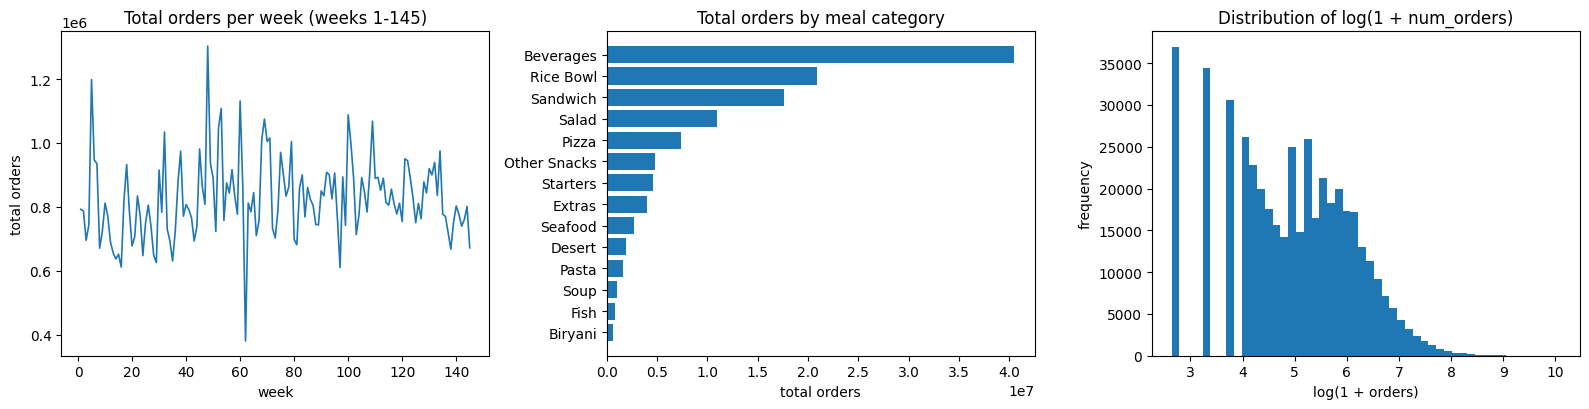

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# 1. Total weekly demand over time -> is there a usable time signal?
weekly = df.groupby("week")["num_orders"].sum()
axes[0].plot(weekly.index, weekly.values, linewidth=1.2)
axes[0].set_title("Total orders per week (weeks 1-145)")
axes[0].set_xlabel("week")
axes[0].set_ylabel("total orders")

# 2. Demand by meal category -> which menu sections carry the volume?
by_category = df.groupby("category")["num_orders"].sum().sort_values()
axes[1].barh(by_category.index, by_category.values)
axes[1].set_title("Total orders by meal category")
axes[1].set_xlabel("total orders")

# 3. Distribution of the label -> confirms the right skew reported above
axes[2].hist(np.log1p(df["num_orders"]), bins=50)
axes[2].set_title("Distribution of log(1 + num_orders)")
axes[2].set_xlabel("log(1 + orders)")
axes[2].set_ylabel("frequency")

plt.tight_layout()
plt.show()

### 5.1 Verdict

| Criterion | Finding |
|---|---|
| Size | 456,548 labelled observations — ample for supervised learning |
| Completeness | 0 missing values, 0 duplicates, referential integrity intact |
| Label quality | `num_orders` is continuous, strictly positive and strongly right-skewed — a `log1p` transform plus RMSLE evaluation is the natural setup |
| Feature richness | Price, discount, two promotion flags, meal category/cuisine, centre location and size |
| Signal present | Promotions visibly lift mean demand, and weekly totals show structure rather than noise |
| Ethics / licensing | Public hackathon data, fully anonymised, no personal data — no DPA 2019 exposure |

**The dataset is suitable** for developing the MloHub demand-prediction engine.



### References

1. Genpact & Analytics Vidhya (2018). *Genpact Machine Learning Hackathon — Food Demand Forecasting.* Data dictionary and problem statement.
2. Kaggle mirrors: `kannanaikkal/food-demand-forecasting`; `ghoshsaptarshi/av-genpact-hack-dec2018`.
3. UCI Machine Learning Repository — *Online Retail II*; *Restaurant & Consumer Data*.
4. Kaggle — *Instacart Market Basket Analysis*; *Store Item Demand Forecasting Challenge*; *Rossmann Store Sales*; *Brazilian E-Commerce Public Dataset by Olist*.
5. Humanitarian Data Exchange — *WFP Food Prices for Kenya*.